/tmp/ipykernel_1891403/2653393129.py:117: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('cool')


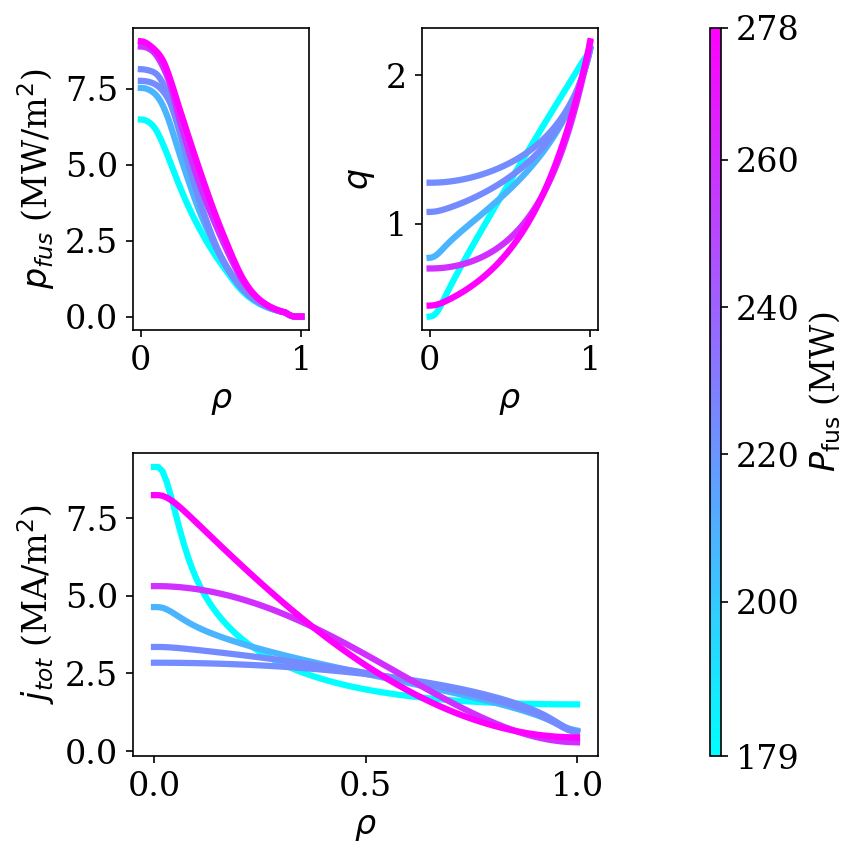

In [6]:
from netCDF4 import Dataset
from sys import argv
import os
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.cm as cm
import numpy as np

with plt.rc_context({
    #"text.usetex": True,
    "font.family": "serif",
    #"font.serif": ["Computer Modern Roman"],
    "font.size": 16,
    "figure.autolayout":True,
    #"legend.frameon" : False,
    "lines.linewidth" : 3.0,
    "lines.markeredgewidth" : 0.0,
    "lines.markersize" : 2.0

}):
    
    fig = plt.figure('fig_offset', figsize=(6,6),dpi = 150)
    gs = mpl.gridspec.GridSpec(2,3, figure=fig, width_ratios=[1,1,0.06])
    axs = {}
    axs[1] = fig.add_subplot(gs[0,0])
    axs[2] = fig.add_subplot(gs[1,0:2])
    axs[3] = fig.add_subplot(gs[0,1])
    axs[4] = fig.add_subplot(gs[:,2])
    #axs[4] = fig.add_subplot(gs[1,1])
    
    ax1 = axs[1]
    ax2 = axs[2]
    ax3 = axs[3]
    axcb = axs[4]
    
    
    # First just find the fastran.nc file ================
    cwd = os.getcwd()
    SCAN_dir = cwd+'/SCAN'
    sims = [f for f in os.listdir(SCAN_dir) if f.startswith('simulation_') and not f.endswith('.conf') and not f.endswith('log')]

    jtot_array_array = []
    q_array_array = []
    pfus_array_array = []
    pfus_array = []
    
    for sim in sims:
        work_dir = SCAN_dir+'/'+sim+'/work'
        
        fastran_dir = [f for f in os.listdir(work_dir) if f.startswith('fastran_tr_')] #initial fastran, change to final fastran if needed
        ffile = work_dir+'/'+fastran_dir[0]+'/fastran.nc'
        #toray_dir = [f for f in os.listdir(work_dir) if f.startswith('fastran_ec_')]
        #toray_file = work_dir+'/'+toray_dir[0]+'/toray.nc'
        
    #=====================================================
    
        rootgrp = Dataset(ffile)
    
        rho = rootgrp['rho'][:]
    
        ne = rootgrp['ne'][-1,:]
        nebar = rootgrp['nebar'][-1]
        ni = rootgrp['ni'][-1,:]
    
        te = rootgrp['te'][-1,:]
        teavg = rootgrp['tea'][-1]
        ti = rootgrp['ti'][-1,:]
        tiavg = rootgrp['tia'][-1]
    
        ipol = rootgrp['ipol'][-1,:]
        ip = rootgrp['ip'][-1]
    
        prfe = rootgrp['pe_rf'][-1,:]
        prfi = rootgrp['pi_rf'][-1,:]
    
        pfuse = rootgrp['pe_fus'][-1,:]
        pfuse_int = rootgrp['pfuse'][-1]
        pfusi = rootgrp['pi_fus'][-1,:]
        pfusi_int = rootgrp['pfusi'][-1]
    
        q = rootgrp['q'][-1,:]
    
        jbs = rootgrp['j_bs'][-1,:]
        ibs = rootgrp['ibs'][-1]
        jrf = rootgrp['j_rf'][-1,:]
        irf = rootgrp['irf'][-1]
        jtot = rootgrp['j_tot'][-1,:]
    
        fluxe = rootgrp['fluxe'][-1,:]
        fluxe_exp = rootgrp['fluxe_exp'][-1,:]
        fluxi = rootgrp['fluxi'][-1,:]
        fluxi_exp = rootgrp['fluxi_exp'][-1,:]

        pfus_array.append(5*(pfuse_int+pfusi_int))

        jtot_array_array.append(jtot)
        q_array_array.append(q)
        pfus_array_array.append(5*(pfuse+pfusi))
    
        #toray_frequency = Dataset(toray_file)['freqcy'][0]/1e9 #in GHz
        
        var_dic = {'ne':ne,'ni':ni,'te':te,'ti':ti,'ipol':ipol,'jtot':jtot,'jbs':jbs,'jrf':jrf,'pfus':5*(pfuse+pfusi),'paux':prfe+prfi,'q':q}
        lw = 2
        c1 = 'green'
        c2 = 'lime'
        c3 = 'magenta'
        c4 = 'darkviolet'
        c5 = 'dodgerblue'
        c6 = 'cyan'


    cvar = pfus_array
    yvar = jtot_array_array
    xvar = rho

    # set colors for colorbar
    cmap = cm.get_cmap('cool')
    cmin = min(cvar)
    cmax = max(cvar)
    cs = (cvar-cmin)/(cmax-cmin)
    c = cmap(cs)
    order = np.argsort(cs)
    
    # make colorbar
    Ncb = 5
    ticklabels = np.array([179,200,220,240,260,278])
    ticks = (ticklabels-min(ticklabels))/(max(ticklabels)-min(ticklabels))
    #ticks = np.linspace(0,1,Ncb); ticklabels = np.linspace(cmin,cmax,Ncb)
    cb1 = mpl.colorbar.ColorbarBase(axcb, orientation='vertical',cmap=cmap, ticks=ticks)
    ticklabels = ['{:1.0f}'.format(x) for x in ticklabels]
    ticklabels[0] = f'{ticklabels[0]}'
    ticklabels[-1] = f'{ticklabels[-1]}'
    cb1.set_ticklabels(ticklabels)

    axcb.set_ylabel('${P_\\mathrm{fus}}$ (MW)')
    
    for i in order:
        ax2.plot(xvar,yvar[i],c=c[i])
        ax3.plot(xvar,q_array_array[i],color=c[i])
        ax1.plot(xvar,pfus_array_array[i],color=c[i])

        
        # ax1.plot(rho,var_dic['jtot'])
        ax2.set_xlabel('$\\rho$')
        ax2.set_ylabel('$j_{tot}$ (MA/m$^2$)')

        # ax2.plot(rho,var_dic['pfus'],label = '$P_\\mathrm{fus} = %.0f$' % (5*(pfuse_int+pfusi_int)))
        ax1.set_xlabel('$\\rho$')
        ax1.set_ylabel('$p_{fus}$ (MW/m$^2$)')
        
        # ax3.plot(rho,var_dic['q'])
        ax3.set_xlabel('$\\rho$')
        ax3.set_ylabel('$q$')

        #print('$P_\\mathrm{fus} = %.0f$' % (5*(pfuse_int+pfusi_int)))
    fig.tight_layout()
    plt.show()